Starting Training...
Episode 1000/50000
  vs Random: W:77 D:5 L:18 (Win%: 77.0%)
  vs Perfect: W:82 D:5 L:13 (Win%: 82.0%)
  Epsilon: 0.2714
------------------------------------------------------------
Episode 2000/50000
  vs Random: W:84 D:7 L:9 (Win%: 84.0%)
  vs Perfect: W:85 D:4 L:11 (Win%: 85.0%)
  Epsilon: 0.2456
------------------------------------------------------------
Episode 3000/50000
  vs Random: W:83 D:8 L:9 (Win%: 83.0%)
  vs Perfect: W:85 D:8 L:7 (Win%: 85.0%)
  Epsilon: 0.2222
------------------------------------------------------------
Episode 4000/50000
  vs Random: W:97 D:3 L:0 (Win%: 97.0%)
  vs Perfect: W:93 D:3 L:4 (Win%: 93.0%)
  Epsilon: 0.2011
------------------------------------------------------------
Episode 5000/50000
  vs Random: W:87 D:4 L:9 (Win%: 87.0%)
  vs Perfect: W:95 D:1 L:4 (Win%: 95.0%)
  Epsilon: 0.1820
------------------------------------------------------------
Episode 6000/50000
  vs Random: W:94 D:4 L:2 (Win%: 94.0%)
  vs Perfect: W:99 D:1

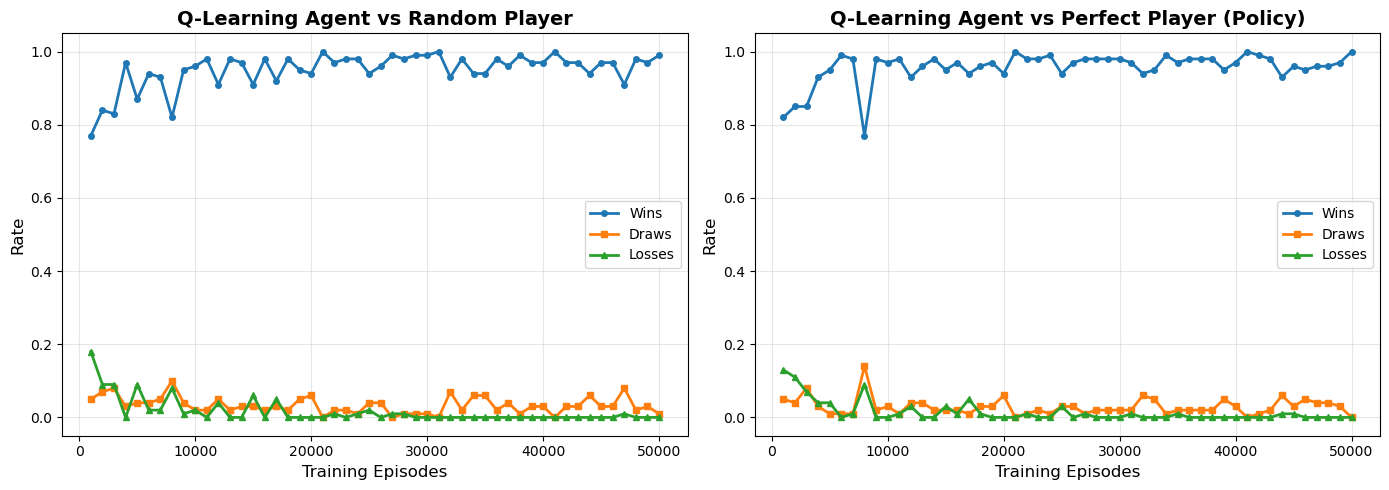


FINAL EVALUATION (1000 games each)

Agent vs Random Player:
  Wins: 989 (98.9%)
  Draws: 11 (1.1%)
  Losses: 0 (0.0%)

Agent vs Perfect Player:
  Wins: 990 (99.0%)
  Draws: 10 (1.0%)
  Losses: 0 (0.0%)

Note: Against a perfect player, the best outcome is a draw.
Wins against perfect play indicate the perfect player went second.

DEMO: Watch the trained agent play against perfect player

Initial board:


. . .
. . .
. . .


Move 1: Q-Agent (X) plays at (2, 2)


. . .
. . .
. . X


Move 2: Perfect (O) plays at (1, 2)


. . .
. . O
. . X


Move 3: Q-Agent (X) plays at (1, 1)


. . .
. X O
. . X


Move 4: Perfect (O) plays at (1, 0)


. . .
O X O
. . X


Move 5: Q-Agent (X) plays at (0, 0)


X . .
O X O
. . X


Q-Agent (X) wins!

Ready to play! Run the function below to start:

>>> play_interactive_menu()

Or call it directly to start playing!
------------------------------------------------------------

TIC-TAC-TOE - Interactive Mode

Choose game mode:
1. Human vs Human
2. Human vs Rando

In [ ]:
"""
Tic-Tac-Toe Reinforcement Learning Training
This notebook implements Q-learning to train an agent to play tic-tac-toe optimally
"""

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import copy
import pickle

# ============================================================================
# PART 1: Computational Framework for Tic-Tac-Toe
# ============================================================================

class TicTacToe:
    """Tic-Tac-Toe game environment"""
    
    def __init__(self):
        self.board = np.zeros((3, 3), dtype=int)
        self.current_player = 1  # 1 for X, -1 for O
        
    def reset(self):
        """Reset the game to initial state"""
        self.board = np.zeros((3, 3), dtype=int)
        self.current_player = 1
        return self.get_state()
    
    def get_state(self):
        """Return board state as tuple for hashing"""
        return tuple(self.board.flatten())
    
    def get_available_actions(self):
        """Return list of available positions"""
        return list(zip(*np.where(self.board == 0)))
    
    def step(self, action):
        """Execute action and return (next_state, reward, done)"""
        row, col = action
        
        if self.board[row, col] != 0:
            # Invalid move
            return self.get_state(), -10, True
        
        # Place piece
        self.board[row, col] = self.current_player
        
        # Check for win
        winner = self.check_winner()
        if winner != 0:
            reward = 1 if winner == self.current_player else -1
            return self.get_state(), reward, True
        
        # Check for draw
        if len(self.get_available_actions()) == 0:
            return self.get_state(), 0, True
        
        # Switch player
        self.current_player *= -1
        return self.get_state(), 0, False
    
    def check_winner(self):
        """Check if there's a winner. Returns 1, -1, or 0"""
        # Check rows
        for i in range(3):
            if abs(sum(self.board[i, :])) == 3:
                return self.board[i, 0]
        
        # Check columns
        for i in range(3):
            if abs(sum(self.board[:, i])) == 3:
                return self.board[0, i]
        
        # Check diagonals
        if abs(sum([self.board[i, i] for i in range(3)])) == 3:
            return self.board[0, 0]
        if abs(sum([self.board[i, 2-i] for i in range(3)])) == 3:
            return self.board[0, 2]
        
        return 0
    
    def render(self):
        """Display the board"""
        symbols = {0: '.', 1: 'X', -1: 'O'}
        print("\n")
        for i in range(3):
            print(" ".join([symbols[self.board[i, j]] for j in range(3)]))
        print("\n")

# ============================================================================
# Player Strategies
# ============================================================================

class RandomPlayer:
    """Player that makes random moves"""
    
    def get_action(self, game, training=False):
        actions = game.get_available_actions()
        return actions[np.random.randint(len(actions))] if actions else None

class PerfectPlayer:
    """Perfect player using pre-computed perfect policy"""
    
    def __init__(self, player_id, policy_file="perfectPolicy.p"):
        self.player_id = player_id
        # Load the perfect policy from pickle file
        self.strategy = pickle.load(open(policy_file, "rb"))
    
    def get_state_key(self, game):
        """Convert game state to policy key format"""
        # The policy expects state from the perspective of the current player
        # We need to adjust the board if we're player -1
        board = game.board.copy()
        if self.player_id == -1:
            # Flip the board perspective for player -1
            board = -board
        return tuple(board.flatten())
    
    def get_action(self, game, training=False):
        """Get best action using perfect policy"""
        state_key = self.get_state_key(game)
        
        # Get available actions
        actions = game.get_available_actions()
        if not actions:
            return None
        
        # Try to get action from policy
        if state_key in self.strategy:
            policy_action = self.strategy[state_key]
            # Convert policy action (index 0-8) to (row, col)
            row, col = policy_action // 3, policy_action % 3
            
            # Verify it's a valid action
            if (row, col) in actions:
                return (row, col)
        
        # Fallback to random action if policy doesn't have this state
        return actions[np.random.randint(len(actions))]

# ============================================================================
# PART 2: Q-Learning Agent
# ============================================================================

class QLearningAgent:
    """Q-Learning agent for tic-tac-toe"""
    
    def __init__(self, player_id=1, alpha=0.1, gamma=0.95, epsilon=0.1):
        self.player_id = player_id
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.q_table = defaultdict(lambda: defaultdict(float))
        
    def get_action(self, game, training=True):
        """Get action using epsilon-greedy policy"""
        state = game.get_state()
        actions = game.get_available_actions()
        
        if not actions:
            return None
        
        # Exploration
        if training and np.random.random() < self.epsilon:
            return actions[np.random.randint(len(actions))]
        
        # Exploitation
        q_values = [self.q_table[state][action] for action in actions]
        max_q = max(q_values)
        best_actions = [a for a, q in zip(actions, q_values) if q == max_q]
        return best_actions[np.random.randint(len(best_actions))]
    
    def update(self, state, action, reward, next_state, done):
        """Update Q-values"""
        current_q = self.q_table[state][action]
        
        if done:
            target_q = reward
        else:
            next_actions = [a for a in [(i, j) for i in range(3) for j in range(3)]]
            max_next_q = max([self.q_table[next_state][a] for a in next_actions])
            target_q = reward + self.gamma * max_next_q
        
        self.q_table[state][action] = current_q + self.alpha * (target_q - current_q)
    
    def set_epsilon(self, epsilon):
        """Update exploration rate"""
        self.epsilon = epsilon

# ============================================================================
# Training and Evaluation Functions
# ============================================================================

def play_game(agent1, agent2, train_agent1=False, train_agent2=False):
    """Play a single game between two agents"""
    game = TicTacToe()
    state = game.reset()
    
    history = []  # Store (state, action, player) for training
    
    while True:
        current_player = game.current_player
        
        # Get action from current player
        if current_player == 1:
            action = agent1.get_action(game, training=train_agent1)
            training = train_agent1
            agent = agent1
        else:
            action = agent2.get_action(game, training=train_agent2)
            training = train_agent2
            agent = agent2
        
        if action is None:
            break
        
        # Store for training
        if training:
            history.append((state, action, current_player))
        
        # Execute action
        next_state, reward, done = game.step(action)
        
        # Update Q-values for training agent
        if training and hasattr(agent, 'update'):
            agent.update(state, action, reward, next_state, done)
        
        if done:
            # Backpropagate rewards to all moves
            winner = game.check_winner()
            for s, a, p in history:
                if hasattr(agent1, 'update') and train_agent1 and p == 1:
                    final_reward = 1 if winner == 1 else (-1 if winner == -1 else 0)
                    agent1.update(s, a, final_reward, next_state, True)
                elif hasattr(agent2, 'update') and train_agent2 and p == -1:
                    final_reward = 1 if winner == -1 else (-1 if winner == 1 else 0)
                    agent2.update(s, a, final_reward, next_state, True)
            
            return winner
        
        state = next_state
    
    return 0

def evaluate_agent(agent, opponent, num_games=100):
    """Evaluate agent performance against opponent"""
    wins = 0
    losses = 0
    draws = 0
    
    for _ in range(num_games):
        result = play_game(agent, opponent, train_agent1=False, train_agent2=False)
        if result == 1:
            wins += 1
        elif result == -1:
            losses += 1
        else:
            draws += 1
    
    return wins, draws, losses

# ============================================================================
# Training Loop
# ============================================================================

print("Starting Training...")
print("=" * 60)

# Initialize agents
q_agent = QLearningAgent(player_id=1, alpha=0.1, gamma=0.95, epsilon=0.3)
random_opponent = RandomPlayer()
perfect_opponent = PerfectPlayer(player_id=-1)

# Training parameters
num_episodes = 50000
eval_interval = 1000
epsilon_decay = 0.9999
min_epsilon = 0.01

# Tracking metrics
eval_points = []
random_win_rates = []
random_draw_rates = []
perfect_win_rates = []
perfect_draw_rates = []

# Training loop
for episode in range(num_episodes):
    # Train against random opponent
    play_game(q_agent, random_opponent, train_agent1=True, train_agent2=False)
    
    # Decay epsilon
    q_agent.set_epsilon(max(min_epsilon, q_agent.epsilon * epsilon_decay))
    
    # Evaluate periodically
    if (episode + 1) % eval_interval == 0:
        # Evaluate vs random
        wins_r, draws_r, losses_r = evaluate_agent(q_agent, random_opponent, num_games=100)
        win_rate_r = wins_r / 100
        draw_rate_r = draws_r / 100
        
        # Evaluate vs perfect
        wins_p, draws_p, losses_p = evaluate_agent(q_agent, perfect_opponent, num_games=100)
        win_rate_p = wins_p / 100
        draw_rate_p = draws_p / 100
        
        eval_points.append(episode + 1)
        random_win_rates.append(win_rate_r)
        random_draw_rates.append(draw_rate_r)
        perfect_win_rates.append(win_rate_p)
        perfect_draw_rates.append(draw_rate_p)
        
        print(f"Episode {episode + 1}/{num_episodes}")
        print(f"  vs Random: W:{wins_r} D:{draws_r} L:{losses_r} (Win%: {win_rate_r*100:.1f}%)")
        print(f"  vs Perfect: W:{wins_p} D:{draws_p} L:{losses_p} (Win%: {win_rate_p*100:.1f}%)")
        print(f"  Epsilon: {q_agent.epsilon:.4f}")
        print("-" * 60)

print("\nTraining Complete!")
print("=" * 60)

# ============================================================================
# Plotting Results
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Agent vs Random
ax1 = axes[0]
ax1.plot(eval_points, random_win_rates, label='Wins', linewidth=2, marker='o', markersize=4)
ax1.plot(eval_points, random_draw_rates, label='Draws', linewidth=2, marker='s', markersize=4)
ax1.plot(eval_points, [1 - w - d for w, d in zip(random_win_rates, random_draw_rates)], 
         label='Losses', linewidth=2, marker='^', markersize=4)
ax1.set_xlabel('Training Episodes', fontsize=12)
ax1.set_ylabel('Rate', fontsize=12)
ax1.set_title('Q-Learning Agent vs Random Player', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([-0.05, 1.05])

# Plot 2: Agent vs Perfect
ax2 = axes[1]
ax2.plot(eval_points, perfect_win_rates, label='Wins', linewidth=2, marker='o', markersize=4)
ax2.plot(eval_points, perfect_draw_rates, label='Draws', linewidth=2, marker='s', markersize=4)
ax2.plot(eval_points, [1 - w - d for w, d in zip(perfect_win_rates, perfect_draw_rates)], 
         label='Losses', linewidth=2, marker='^', markersize=4)
ax2.set_xlabel('Training Episodes', fontsize=12)
ax2.set_ylabel('Rate', fontsize=12)
ax2.set_title('Q-Learning Agent vs Perfect Player (Policy)', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()

# ============================================================================
# Final Evaluation
# ============================================================================

print("\n" + "=" * 60)
print("FINAL EVALUATION (1000 games each)")
print("=" * 60)

# Final evaluation vs Random
wins_r, draws_r, losses_r = evaluate_agent(q_agent, random_opponent, num_games=1000)
print(f"\nAgent vs Random Player:")
print(f"  Wins: {wins_r} ({wins_r/10:.1f}%)")
print(f"  Draws: {draws_r} ({draws_r/10:.1f}%)")
print(f"  Losses: {losses_r} ({losses_r/10:.1f}%)")

# Final evaluation vs Perfect
wins_p, draws_p, losses_p = evaluate_agent(q_agent, perfect_opponent, num_games=1000)
print(f"\nAgent vs Perfect Player:")
print(f"  Wins: {wins_p} ({wins_p/10:.1f}%)")
print(f"  Draws: {draws_p} ({draws_p/10:.1f}%)")
print(f"  Losses: {losses_p} ({losses_p/10:.1f}%)")

print("\n" + "=" * 60)
print("Note: Against a perfect player, the best outcome is a draw.")
print("Wins against perfect play indicate the perfect player went second.")
print("=" * 60)

# ============================================================================
# Demo Game
# ============================================================================

print("\n" + "=" * 60)
print("DEMO: Watch the trained agent play against perfect player")
print("=" * 60)

demo_game = TicTacToe()
demo_game.reset()
print("\nInitial board:")
demo_game.render()

move_count = 0
while True:
    current_player = demo_game.current_player
    
    if current_player == 1:
        action = q_agent.get_action(demo_game, training=False)
        player_name = "Q-Agent (X)"
    else:
        action = perfect_opponent.get_action(demo_game)
        player_name = "Perfect (O)"
    
    if action is None:
        break
    
    move_count += 1
    print(f"Move {move_count}: {player_name} plays at {action}")
    _, _, done = demo_game.step(action)
    demo_game.render()
    
    if done:
        winner = demo_game.check_winner()
        if winner == 1:
            print("Q-Agent (X) wins!")
        elif winner == -1:
            print("Perfect Player (O) wins!")
        else:
            print("Draw!")
        break

# ============================================================================
# Interactive Player
# ============================================================================

class HumanPlayer:
    """Human player for interactive games"""
    
    def get_action(self, game, training=False):
        """Get action from human input"""
        actions = game.get_available_actions()
        
        if not actions:
            return None
        
        print("\nAvailable positions:")
        position_map = {}
        pos_num = 1
        
        # Create position mapping
        for i in range(3):
            for j in range(3):
                if game.board[i, j] == 0:
                    position_map[pos_num] = (i, j)
                    pos_num += 1
        
        # Display board with numbers for available positions
        print("\n")
        for i in range(3):
            row_display = []
            for j in range(3):
                val = game.board[i, j]
                if val == 1:
                    row_display.append('X')
                elif val == -1:
                    row_display.append('O')
                else:
                    # Find the position number for this empty cell
                    pos_found = False
                    for pos, coord in position_map.items():
                        if coord == (i, j):
                            row_display.append(str(pos))
                            pos_found = True
                            break
                    if not pos_found:
                        row_display.append('.')
            print(" ".join(row_display))
        print("\n")
        
        while True:
            try:
                choice = int(input("Enter position number: "))
                if choice in position_map:
                    return position_map[choice]
                else:
                    print("Invalid position. Try again.")
            except ValueError:
                print("Please enter a number.")
            except KeyboardInterrupt:
                print("\nGame cancelled.")
                return None

def play_interactive_game(player1, player2, player1_name="Player 1", player2_name="Player 2"):
    """Play an interactive game with visual feedback"""
    game = TicTacToe()
    game.reset()
    
    print(f"\n{'='*60}")
    print(f"{player1_name} (X) vs {player2_name} (O)")
    print(f"{'='*60}")
    print("\nStarting board:")
    game.render()
    
    move_count = 0
    while True:
        current_player = game.current_player
        
        if current_player == 1:
            print(f"\n{player1_name}'s turn (X):")
            action = player1.get_action(game, training=False)
            player_name = player1_name
        else:
            print(f"\n{player2_name}'s turn (O):")
            action = player2.get_action(game, training=False)
            player_name = player2_name
        
        if action is None:
            print("Game cancelled or no moves available.")
            break
        
        move_count += 1
        print(f"\n{player_name} plays at position ({action[0]}, {action[1]})")
        _, _, done = game.step(action)
        game.render()
        
        if done:
            winner = game.check_winner()
            print(f"{'='*60}")
            if winner == 1:
                print(f"{player1_name} (X) wins! 🎉")
            elif winner == -1:
                print(f"{player2_name} (O) wins! 🎉")
            else:
                print("It's a draw! 🤝")
            print(f"{'='*60}")
            break
    
    return game.check_winner()

# ============================================================================
# Interactive Game Menu
# ============================================================================

def play_interactive_menu():
    """Interactive menu for playing games"""
    human = HumanPlayer()
    
    while True:
        print("\n" + "="*60)
        print("TIC-TAC-TOE - Interactive Mode")
        print("="*60)
        print("\nChoose game mode:")
        print("1. Human vs Human")
        print("2. Human vs Random Agent")
        print("3. Human vs Trained Q-Agent")
        print("4. Human vs Perfect Agent")
        print("5. Exit")
        print("-"*60)
        
        try:
            choice = input("\nEnter your choice (1-5): ").strip()
            
            if choice == '1':
                play_interactive_game(human, HumanPlayer(), "Player 1", "Player 2")
            elif choice == '2':
                play_interactive_game(human, random_opponent, "You", "Random Agent")
            elif choice == '3':
                play_interactive_game(human, q_agent, "You", "Trained Q-Agent")
            elif choice == '4':
                play_interactive_game(human, perfect_opponent, "You", "Perfect Agent")
            elif choice == '5':
                print("\nThanks for playing! Goodbye! 👋")
                break
            else:
                print("\nInvalid choice. Please enter 1-5.")
                
            if choice in ['1', '2', '3', '4']:
                play_again = input("\nPlay again? (y/n): ").strip().lower()
                if play_again != 'y':
                    print("\nThanks for playing! Goodbye! 👋")
                    break
                    
        except KeyboardInterrupt:
            print("\n\nThanks for playing! Goodbye! 👋")
            break
        except Exception as e:
            print(f"\nAn error occurred: {e}")
            print("Let's try again...")

# Start the interactive menu
print("\n" + "="*60)
print("Ready to play! Run the function below to start:")
print("="*60)
print("\n>>> play_interactive_menu()")
print("\nOr call it directly to start playing!")
print("-"*60)

# Uncomment the line below to automatically start the interactive menu
play_interactive_menu()